# Homo Moralis in Madoka Magica
## Three-Type Evolutionary Game — Concave Public Goods Game
## 三类型进化博弈——凹型公共品博弈

| Character | Type | Utility | Strategy |
|---|---|---|---|
| Sakura Kyoko 佐仓杏子 | Homo Oeconomicus | $u_K = \pi(x,y)$ | $x_K^* = \frac{r-1}{2r}$ |
| Tomoe Mami 巴麻美 | Pure Kantian | $u_M = \pi(x,x)$ | $x_M^* = \frac{2r-1}{4r}$ (social optimum) |
| Miki Sayaka 美树沙耶香 | Pure Altruist | $u_S = \pi(y,x)$ | $x_S^* = \frac{1}{2}$ |

**Key insight / 核心洞见:** ordering $x_K^* < x_M^* < x_S^*$ holds for all $r > 1$.
Mami's Kantian strategy **coincides with the social optimum**.
Sayaka **over-contributes** — she hurts herself without proportional benefit.

巴麻美的康德策略**恰好等于社会最优**。沙耶香**过度贡献**——以超出最优的投入伤害自己。

**Kyubey's mechanism / 丘比机制:**
- Population constant: deaths = entries each period / 种群恒定：每期死亡数 = 进入数
- Entry drawn from current composition / 新进入者按当前构成比例抽取
- Selection via standard replicator: $\Delta s_i = s_i(f_i - \bar{f})$ / 标准复制动态选择

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Load CJK font so Chinese renders in plots / 加载CJK字体确保中文显示
_cjk = ['Microsoft YaHei', 'SimHei', 'SimSun', 'Noto Sans CJK SC']
_avail = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _cjk if f in _avail), None)
if _font:
    plt.rcParams['font.family'] = [_font, 'DejaVu Sans']
    print(f'CJK font: {_font}')
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 13,
                     'figure.dpi': 120, 'axes.unicode_minus': False})

CJK font: Microsoft YaHei


## 1. Game Setup / 博弈设置

**Concave Public Goods Game / 凹型公共品博弈:**

$$\pi(x_i, x_j) = r(x_i + x_j) - \frac{r(x_i+x_j)^2}{2} - x_i, \quad r > 1$$

The marginal return to total contribution is **decreasing** (congestion / 拥挤效应).
Social dilemma persists: each player wants to free-ride on the other's contribution.
边际回报递减，社会困境依然存在：每个人都有搭便车动机。

**Equilibrium strategies / 均衡策略:**

| Type | Utility maximised | FOC | $x^*$ |
|---|---|---|---|
| Kyoko | $\pi(x,y)$ | $r - r(x+y) - 1 = 0$ | $x_K^* = \frac{r-1}{2r}$ |
| Mami | $\pi(x,x)$ | $(2r-1) - 4rx = 0$ | $x_M^* = \frac{2r-1}{4r} = x_{\text{social}}^*$ |
| Sayaka | $\pi(y,x)$ | $r(1 - x_j - x_i) = 0 \Rightarrow x_i = 1-x_j$ | $x_S^* = \frac{1}{2}$ |

Ordering: $x_K^* < x_M^* < x_S^* = \frac{1}{2}$, all distinct for any $r > 1$.
大小关系：对任意 $r>1$，三者均衡策略均不同。

In [2]:
# Public Goods Game parameter / 公共品博弈参数
r = 3.0   # return rate on public good / 公共品回报率 (r > 1 for social dilemma)

# Payoff function / 收益函数
def pi(x, y):
    # pi(x_i, x_j) = r*(x_i+x_j) - r*(x_i+x_j)^2/2 - x_i
    # 公共品博弈：双方贡献之和产生凹型回报，减去自身贡献成本
    z = x + y
    return r * z - r * z**2 / 2 - x

# Equilibrium strategies (derived from utility maximisation)
# 均衡策略（由各自效用函数最大化导出）

# Kyoko: max pi(x,y) -> FOC: r - r(x+y) - 1 = 0
# At symmetric NE: x_K* = (r-1)/(2r)
# 杏子：对称纳什均衡，部分搭便车
x_K = (r - 1) / (2 * r)

# Mami (pure Kantian): max pi(x,x) = r*2x - r*(2x)^2/2 - x
# FOC: (2r-1) - 4rx = 0 -> x_M* = (2r-1)/(4r)
# This equals the social optimum: arg max [pi(x,x) + pi(x,x)]
# 巴麻美：康德最优 = 社会最优（社会计划者解）
x_M = (2 * r - 1) / (4 * r)

# Social optimum (for reference) / 社会最优（供参考）
x_soc = (2 * r - 1) / (4 * r)   # same as x_M — Kantian result!

# Sayaka (pure altruist): max pi(y,x) w.r.t. x
# pi(y,x) = r*(y+x) - r*(y+x)^2/2 - y
# FOC: r - r*(y+x) = 0 -> x = 1 - y
# At symmetric NE vs another Sayaka: x_S* = 1 - x_S* -> x_S* = 1/2
# 沙耶香：最大化对方收益，对称均衡为1/2（与r无关）
x_S = 0.5

STRATEGIES = np.array([x_K, x_M, x_S])
NAMES  = ['Kyoko 杏子', 'Mami 巴麻美', 'Sayaka 沙耶香']
COLORS = ['#e74c3c', '#f39c12', '#3498db']

print(f'r = {r}')
print(f'  Kyoko   x_K* = {x_K:.4f}   (partial free-rider / 部分搭便车)')
print(f'  Mami    x_M* = {x_M:.4f}   (= social optimum / 等于社会最优)')
print(f'  Sayaka  x_S* = {x_S:.4f}   (over-contributor / 过度贡献)')
print(f'  Social optimum x* = {x_soc:.4f}')
print()
print('Own-type payoffs / 与同类对战收益:')
for name, x in zip(NAMES, STRATEGIES):
    print(f'  {name}: pi(x*,x*) = {pi(x,x):.4f}')

r = 3.0
  Kyoko   x_K* = 0.3333   (partial free-rider / 部分搭便车)
  Mami    x_M* = 0.4167   (= social optimum / 等于社会最优)
  Sayaka  x_S* = 0.5000   (over-contributor / 过度贡献)
  Social optimum x* = 0.4167

Own-type payoffs / 与同类对战收益:
  Kyoko 杏子: pi(x*,x*) = 1.0000
  Mami 巴麻美: pi(x*,x*) = 1.0417
  Sayaka 沙耶香: pi(x*,x*) = 1.0000


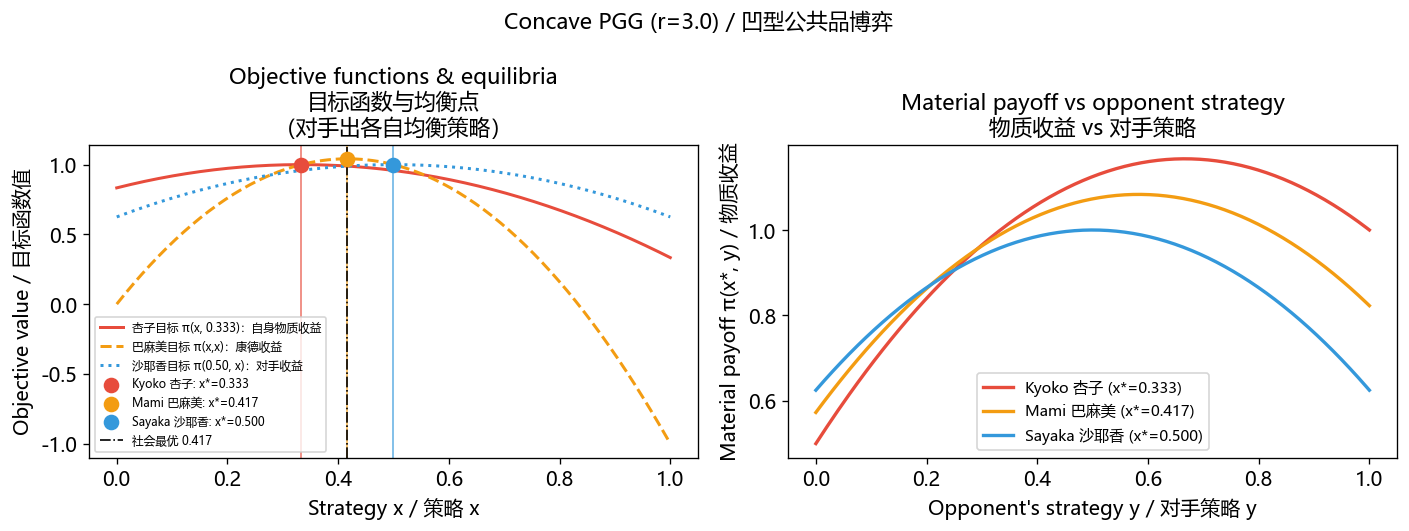

In [3]:
# Plot payoff functions and equilibrium points
# 绘制收益函数和均衡点
xgrid = np.linspace(0, 1, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: each type's objective function, opponent fixed at *that type's own* equilibrium
# 左图：各类型目标函数，对手固定出该类型自身的均衡策略
# => 三条线的峰值恰好落在各自均衡竖线上
ax = axes[0]
ax.plot(xgrid, [pi(x, x_K) for x in xgrid],
        color=COLORS[0], lw=1.8,
        label=f'杏子目标 π(x, {x_K:.3f})：自身物质收益')
ax.plot(xgrid, [pi(x, x) for x in xgrid],
        color=COLORS[1], lw=1.8, ls='--',
        label='巴麻美目标 π(x,x)：康德收益')
ax.plot(xgrid, [pi(x_S, x) for x in xgrid],
        color=COLORS[2], lw=1.8, ls=':',
        label=f'沙耶香目标 π({x_S:.2f}, x)：对手收益')

for x, c_, name in zip(STRATEGIES, COLORS, NAMES):
    ax.axvline(x, color=c_, lw=1.2, alpha=0.6)
    ax.scatter([x], [pi(x, x)], color=c_, s=70, zorder=5,
               label=f'{name}: x*={x:.3f}')
ax.axvline(x_soc, color='black', lw=1, ls='-.', label=f'社会最优 {x_soc:.3f}')
ax.set_xlabel('Strategy x / 策略 x')
ax.set_ylabel('Objective value / 目标函数值')
ax.set_title('Objective functions & equilibria\n目标函数与均衡点\n（对手出各自均衡策略）')
ax.legend(fontsize=7)

# Right: material payoff as opponent's strategy varies
# 右图：固定各自均衡策略，物质收益随对手策略变化
ax = axes[1]
for x, c_, name in zip(STRATEGIES, COLORS, NAMES):
    ax.plot(xgrid, [pi(x, y) for y in xgrid], color=c_, lw=2,
            label=f'{name} (x*={x:.3f})')
ax.set_xlabel("Opponent's strategy y / 对手策略 y")
ax.set_ylabel('Material payoff π(x*, y) / 物质收益')
ax.set_title('Material payoff vs opponent strategy\n物质收益 vs 对手策略')
ax.legend(fontsize=9)

plt.suptitle(f'Concave PGG (r={r}) / 凹型公共品博弈', fontsize=13)
plt.tight_layout()
plt.savefig('madoka_strategies.png', dpi=150)
plt.show()

## 2. Fitness and Replicator Dynamics / 适应度与复制动态

With assortativity $\sigma$, the average material payoff (fitness) of type $i$ is:
$$f_i = \sigma\,\pi(x_i^*, x_i^*) + (1-\sigma)\sum_j s_j\,\pi(x_i^*, x_j^*)$$

Kyubey replicator (constant population, entry = current composition):
$$s_i(t+1) = s_i(t) + s_i(t)\,(f_i(t) - \bar{f}(t)), \quad \bar{f} = \sum_j s_j f_j$$

No artificial parameters needed — the three types are distinguished purely by their game-theoretic strategies.
无需额外参数——三种类型完全由博弈论策略自然区分。

In [4]:
def fitness(s, sigma):
    # Average payoff for each type with assortativity sigma
    # 在同类匹配概率sigma下，每种类型的平均收益
    f_self  = np.array([pi(x_K, x_K), pi(x_M, x_M), pi(x_S, x_S)])
    # Cross payoff: pi(x_i*, mean opponent strategy)
    # 与全体种群匹配的收益（利用双线性近似）
    # Note: pi is NOT bilinear so we use explicit averaging over types
    # 注意：pi是非线性的，需对各类型显式求和
    f_cross = np.array([
        s[0]*pi(x_K, x_K) + s[1]*pi(x_K, x_M) + s[2]*pi(x_K, x_S),
        s[0]*pi(x_M, x_K) + s[1]*pi(x_M, x_M) + s[2]*pi(x_M, x_S),
        s[0]*pi(x_S, x_K) + s[1]*pi(x_S, x_M) + s[2]*pi(x_S, x_S),
    ])
    return sigma * f_self + (1.0 - sigma) * f_cross


def simulate(s0, sigma, n_steps):
    # Standard replicator dynamics / 标准复制动态
    # ds_i = s_i * (f_i - f_bar)
    s = np.array(s0, dtype=float)
    history = np.zeros((n_steps + 1, 3))
    history[0] = s
    for t in range(n_steps):
        f      = fitness(s, sigma)
        f_bar  = s @ f
        s      = s + s * (f - f_bar)
        s      = np.clip(s, 0, 1)
        s     /= s.sum()
        history[t + 1] = s
    return history


# Verify fitness ordering at equal shares / 验证等份额时的适应度排序
s_equal = np.array([1/3, 1/3, 1/3])
print('Fitness at equal shares (sigma=0) / 等份额时适应度（sigma=0）:')
f0 = fitness(s_equal, 0.0)
for name, fi in zip(NAMES, f0):
    print(f'  {name}: f = {fi:.4f}')
print()
print('Fitness at equal shares (sigma=1) / 等份额时适应度（sigma=1）:')
f1 = fitness(s_equal, 1.0)
for name, fi in zip(NAMES, f1):
    print(f'  {name}: f = {fi:.4f}')

Fitness at equal shares (sigma=0) / 等份额时适应度（sigma=0）:
  Kyoko 杏子: f = 1.0660
  Mami 巴麻美: f = 1.0347
  Sayaka 沙耶香: f = 0.9826

Fitness at equal shares (sigma=1) / 等份额时适应度（sigma=1）:
  Kyoko 杏子: f = 1.0000
  Mami 巴麻美: f = 1.0417
  Sayaka 沙耶香: f = 1.0000


In [5]:
N_STEPS      = 800
S0           = [1/3, 1/3, 1/3]
SIGMA_VALS   = [0.0, 0.25, 0.40, 0.80]
SIGMA_COLORS = ['#c0392b', '#e67e22', '#27ae60', '#2980b9']

results = {sigma: simulate(S0, sigma, N_STEPS) for sigma in SIGMA_VALS}

print('Final shares / 最终份额:')
for sigma in SIGMA_VALS:
    f = results[sigma][-1]
    print(f'  sigma={sigma}: Kyoko={f[0]:.3f}  Mami={f[1]:.3f}  Sayaka={f[2]:.3f}')

Final shares / 最终份额:
  sigma=0.0: Kyoko=1.000  Mami=0.000  Sayaka=0.000
  sigma=0.25: Kyoko=0.807  Mami=0.193  Sayaka=0.000
  sigma=0.4: Kyoko=0.214  Mami=0.786  Sayaka=0.000
  sigma=0.8: Kyoko=0.000  Mami=1.000  Sayaka=0.000


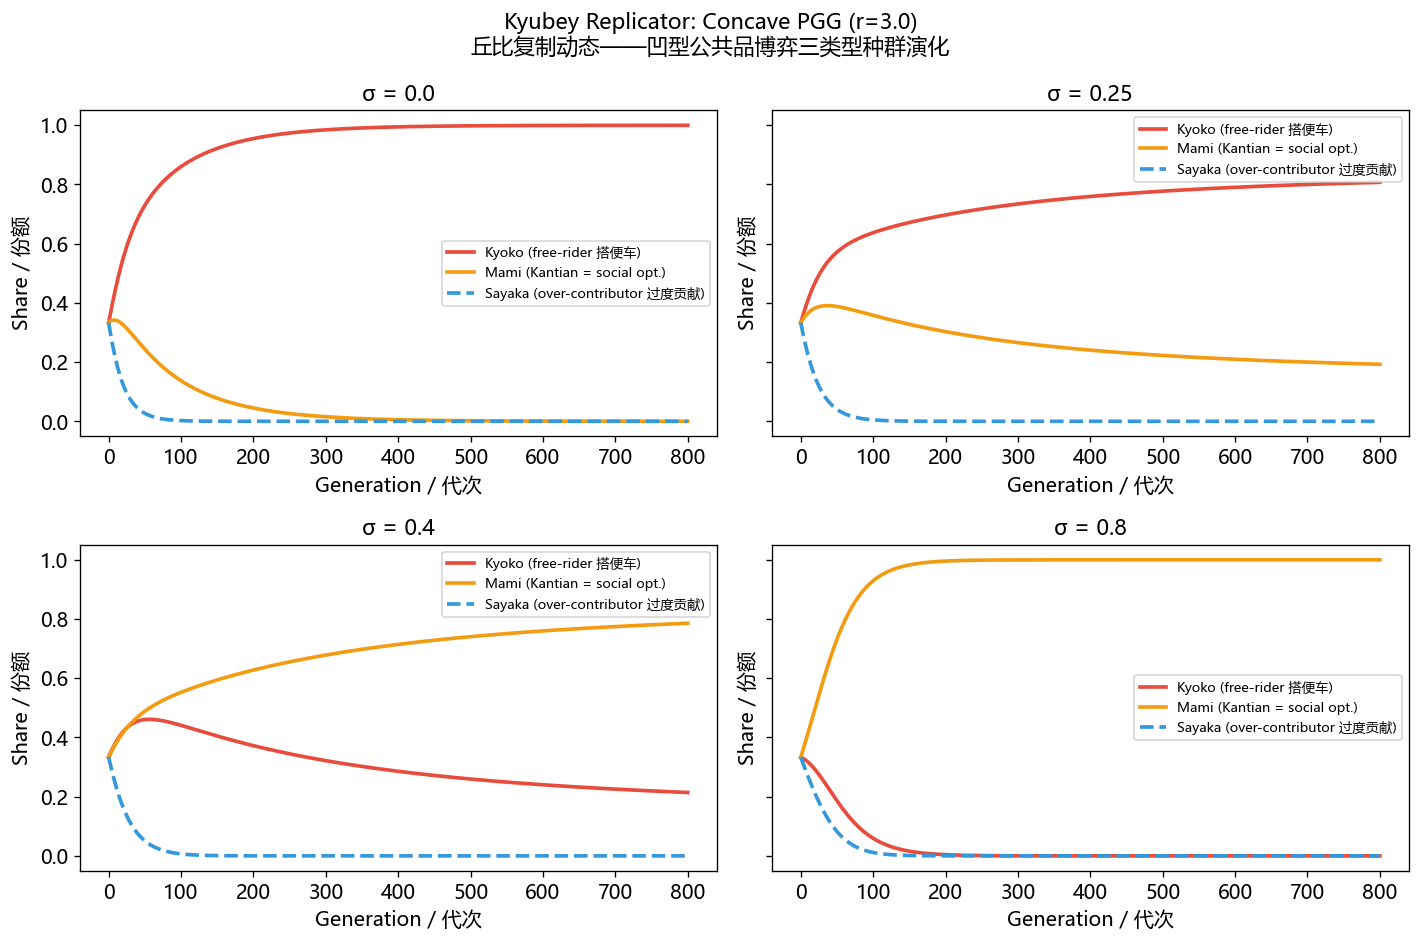

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for ax, sigma in zip(axes.flatten(), SIGMA_VALS):
    hs = results[sigma]
    t  = np.arange(N_STEPS + 1)
    ax.plot(t, hs[:, 0], color=COLORS[0], lw=2.2, label='Kyoko (free-rider 搭便车)')
    ax.plot(t, hs[:, 1], color=COLORS[1], lw=2.2, label='Mami (Kantian = social opt.)')
    ax.plot(t, hs[:, 2], color=COLORS[2], lw=2.2, ls='--', label='Sayaka (over-contributor 过度贡献)')
    ax.set_title(f'σ = {sigma}')
    ax.set_xlabel('Generation / 代次')
    ax.set_ylabel('Share / 份额')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
fig.suptitle(
    f'Kyubey Replicator: Concave PGG (r={r})\n'
    '丘比复制动态——凹型公共品博弈三类型种群演化',
    fontsize=13
)
plt.tight_layout()
plt.savefig('madoka_population.png', dpi=150)
plt.show()

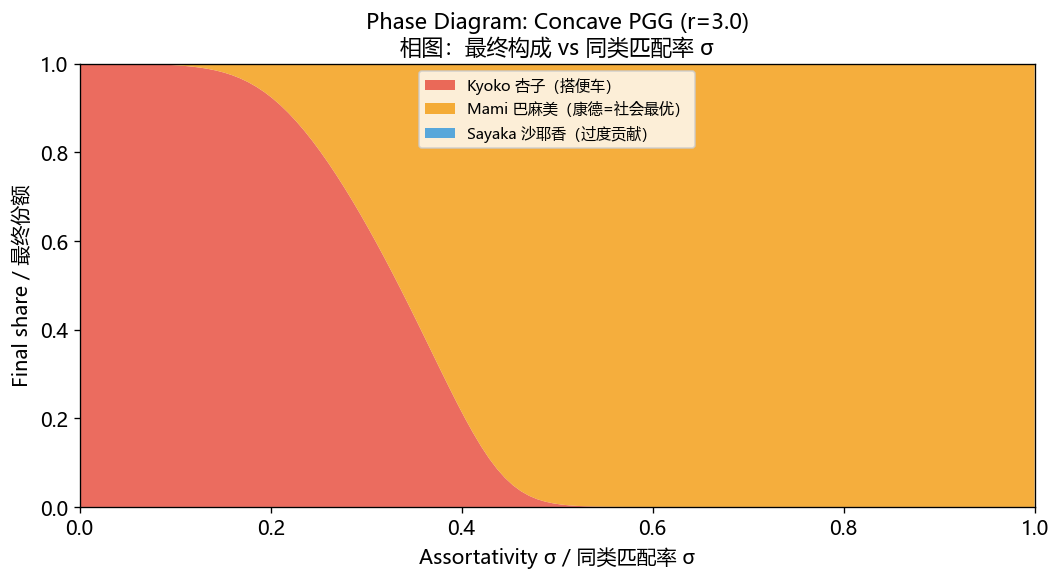

In [7]:
sigma_grid   = np.linspace(0, 1, 120)
final_shares = np.zeros((len(sigma_grid), 3))
for i, sigma in enumerate(sigma_grid):
    final_shares[i] = simulate(S0, sigma, N_STEPS)[-1]

fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(sigma_grid,
             final_shares[:, 0], final_shares[:, 1], final_shares[:, 2],
             labels=['Kyoko 杏子（搭便车）',
                     'Mami 巴麻美（康德=社会最优）',
                     'Sayaka 沙耶香（过度贡献）'],
             colors=COLORS, alpha=0.82)
ax.set_xlabel('Assortativity σ / 同类匹配率 σ')
ax.set_ylabel('Final share / 最终份额')
ax.set_title(
    f'Phase Diagram: Concave PGG (r={r})\n'
    '相图：最终构成 vs 同类匹配率 σ'
)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(loc='upper center', fontsize=9)
plt.tight_layout()
plt.savefig('madoka_phase.png', dpi=150)
plt.show()

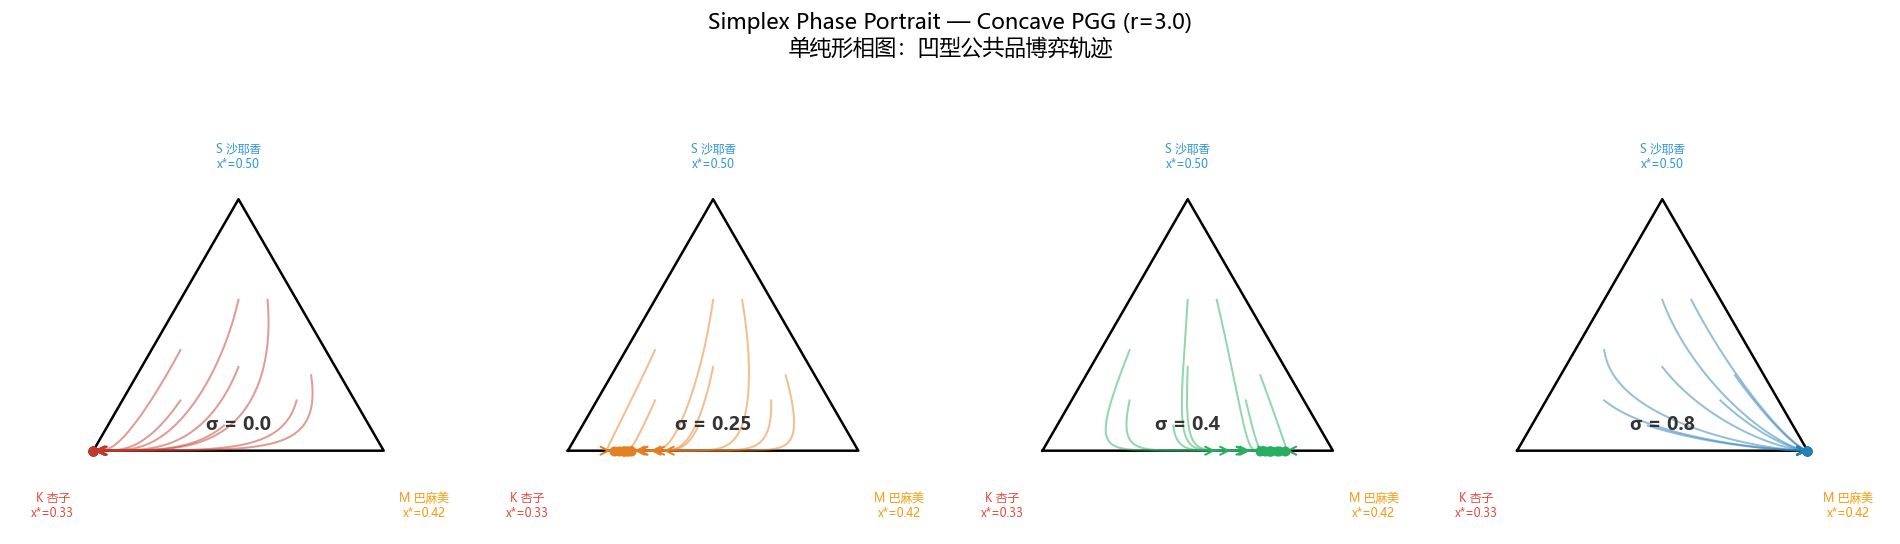

In [8]:
def to_cart(sK, sM, sS):
    return sM + 0.5*sS, (np.sqrt(3)/2)*sS

def draw_simplex(ax, sigma):
    vx = [0, 1, 0.5, 0]; vy = [0, 0, np.sqrt(3)/2, 0]
    ax.plot(vx, vy, 'k-', lw=1.5)
    # Corner labels — moved clear of triangle edges
    ax.text(-0.14, -0.14, f'K 杏子\nx*={x_K:.2f}',
            ha='center', va='top', fontsize=7, color=COLORS[0])
    ax.text( 1.14, -0.14, f'M 巴麻美\nx*={x_M:.2f}',
            ha='center', va='top', fontsize=7, color=COLORS[1])
    ax.text(  0.5,  np.sqrt(3)/2 + 0.10, f'S 沙耶香\nx*={x_S:.2f}',
            ha='center', va='bottom', fontsize=7, color=COLORS[2])
    # σ label inside triangle (bottom centre) to avoid overlap with top label
    ax.text(  0.5,  0.06, f'σ = {sigma}',
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')
    ax.set_aspect('equal')
    ax.axis('off')
    # Expand axis limits so corner labels aren't clipped
    ax.set_xlim(-0.28, 1.28)
    ax.set_ylim(-0.28, np.sqrt(3)/2 + 0.22)

starts = [
    [1/3, 1/3, 1/3],
    [0.1, 0.6, 0.3], [0.1, 0.3, 0.6],
    [0.6, 0.2, 0.2], [0.2, 0.6, 0.2], [0.2, 0.2, 0.6],
    [0.5, 0.4, 0.1], [0.5, 0.1, 0.4],
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, sigma, sc in zip(axes, SIGMA_VALS, SIGMA_COLORS):
    draw_simplex(ax, sigma)
    for s0t in starts:
        hs = simulate(s0t, sigma, N_STEPS)
        xs, ys = to_cart(hs[:, 0], hs[:, 1], hs[:, 2])
        ax.plot(xs, ys, color=sc, alpha=0.5, lw=1.2)
        mid = len(xs) // 2
        ax.annotate('', xy=(xs[mid+5], ys[mid+5]), xytext=(xs[mid], ys[mid]),
                    arrowprops=dict(arrowstyle='->', color=sc, lw=1.2))
        ax.scatter(xs[-1], ys[-1], color=sc, s=25, zorder=5)

fig.suptitle(
    f'Simplex Phase Portrait — Concave PGG (r={r})\n'
    '单纯形相图：凹型公共品博弈轨迹',
    fontsize=13
)
plt.tight_layout()
plt.savefig('madoka_simplex.png', dpi=150)
plt.show()

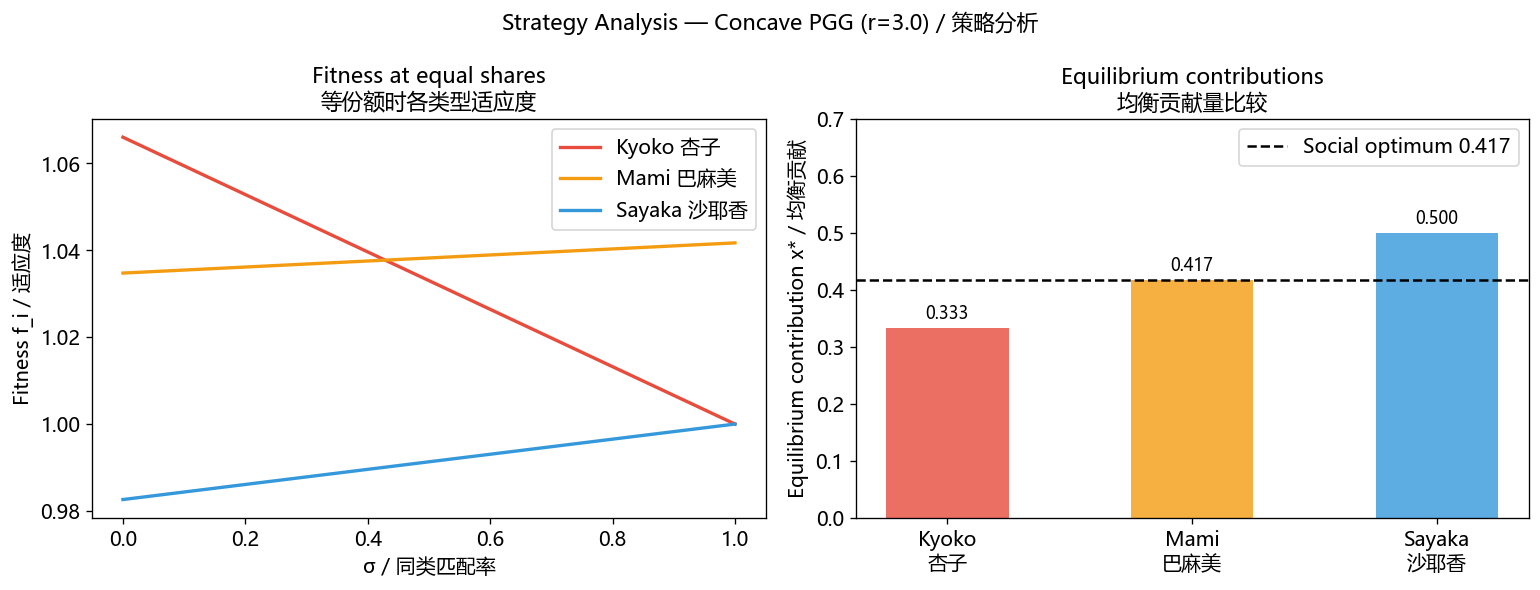

In [9]:
# Fitness of each type as sigma varies, at the final steady state
# 每种类型的适应度随sigma变化（最终稳态下）
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fitness at equal initial shares, sigma sweep
f_grid = np.zeros((len(sigma_grid), 3))
for i, sigma in enumerate(sigma_grid):
    f_grid[i] = fitness(np.array([1/3, 1/3, 1/3]), sigma)

ax = axes[0]
for j, (name, col) in enumerate(zip(NAMES, COLORS)):
    ax.plot(sigma_grid, f_grid[:, j], color=col, lw=2, label=name)
ax.set_xlabel('σ / 同类匹配率')
ax.set_ylabel('Fitness f_i / 适应度')
ax.set_title('Fitness at equal shares\n等份额时各类型适应度')
ax.legend()

# Right: contribution levels x* for reference
ax = axes[1]
bar_w = 0.25
x_pos = np.array([0, 1, 2])
bars = ax.bar(x_pos, STRATEGIES, color=COLORS, width=0.5, alpha=0.8)
ax.axhline(x_soc, color='black', ls='--', lw=1.5, label=f'Social optimum {x_soc:.3f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Kyoko\n杏子', 'Mami\n巴麻美', 'Sayaka\n沙耶香'])
ax.set_ylabel('Equilibrium contribution x* / 均衡贡献')
ax.set_title('Equilibrium contributions\n均衡贡献量比较')
ax.set_ylim(0, 0.7)
ax.legend()
for bar, x in zip(bars, STRATEGIES):
    ax.text(bar.get_x() + bar.get_width()/2, x + 0.01, f'{x:.3f}',
            ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Strategy Analysis — Concave PGG (r={r}) / 策略分析', fontsize=13)
plt.tight_layout()
plt.savefig('madoka_fitness.png', dpi=150)
plt.show()

## Summary / 总结

| Regime | Winner | Why |
|---|---|---|
| Low $\sigma$ | Kyoko 杏子 | Free-riding pays when strangers match / 陌生人相遇时搭便车占优 |
| High $\sigma$ | Mami 巴麻美 | Assortative matching rewards Kantian optimum / 同类匹配奖励康德最优 |
| Any $\sigma$ | Sayaka ≺ Mami | Over-contribution always hurts relative to social optimum / 过度贡献始终劣于社会最优 |

**Why Mami dominates Sayaka at all $\sigma$ / 为何巴麻美在任意σ下均优于沙耶香:**

Mami plays $x_M^* = x_{\text{social}}^*$: the contribution level that maximises **total welfare**.
Because the concave PGG has diminishing returns, Sayaka's extra contribution beyond $x_M^*$
produces less public good than it costs — she makes herself worse off without helping others more.

巴麻美的策略 $x_M^* = x_{\text{social}}^*$ 最大化**社会总福利**。
在凹型公共品博弈中，沙耶香超出 $x_M^*$ 的额外贡献产生的公共品少于其付出的成本——
她在没有更多帮助他人的情况下伤害了自己。

**No artificial parameters needed.**
The $\delta$ correction from the PD version is gone — the three types are naturally distinct.

**无需额外参数。** PD版本中的δ修正已被去除——三种类型在博弈论上自然不同。